<a href="https://colab.research.google.com/github/FahimAlaviRidoy/FineTune_LoRA_QLoRA/blob/main/LLM_FineTuning_LoRA_QLoRA_(Final).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧠 Fine-Tuning an LLM for Medical Q&A Using LoRA & QLoRA

**Objective:** Fine-tune a large language model (`facebook/opt-1.3b`) on the **MedQuAD** (Medical Question Answering Dataset) for domain-specific medical question answering using both LoRA and QLoRA strategies.

---

## 📋 Table of Contents
1. [Introduction & Setup](#1)
2. [Install Dependencies](#2)
3. [Dataset Loading & Exploration](#3)
4. [Data Preprocessing](#4)
5. [Model & Tokenizer Setup](#5)
6. [LoRA Configuration](#6)
7. [QLoRA Configuration (4-bit Quantization)](#7)
8. [Training with LoRA](#8)
9. [Training with QLoRA](#9)
10. [Evaluation & Inference](#10)
11. [Comparison: LoRA vs QLoRA](#11)
12. [Save & Export Models](#12)
13. [Conclusion](#13)

---
## 1. Introduction & Setup <a id='1'></a>

### What is LoRA?
**LoRA (Low-Rank Adaptation)** is a parameter-efficient fine-tuning technique that freezes the pre-trained model weights and injects trainable rank-decomposition matrices into each layer of the Transformer. This reduces the number of trainable parameters significantly.

Instead of updating the full weight matrix `W ∈ R^(d×d)`, LoRA decomposes the update as:
$$\Delta W = BA \quad \text{where } B \in \mathbb{R}^{d \times r},\ A \in \mathbb{R}^{r \times d},\ r \ll d$$

### What is QLoRA?
**QLoRA (Quantized LoRA)** extends LoRA by quantizing the frozen base model to **4-bit precision** (using NF4 or INT4), reducing GPU memory usage drastically while maintaining quality close to full fine-tuning.

### Dataset: MedQuAD
We use a subset from the **medalpaca/medical_meadow_medqa** dataset on HuggingFace, which is derived from MedQuAD — a medical question answering dataset from NIH/NLM.

| Property | Value |
|---|---|
| Domain | Medical Q&A |
| Source | HuggingFace Hub (medalpaca) |
| Format | Instruction → Output |
| Task | Causal Language Modeling (text generation) |

---
## 2. Install Dependencies <a id='2'></a>

In [1]:
# Install required packages
# transformers>=4.41.0 required by sentence-transformers 5.x
!pip install -q "transformers>=4.41.0,<6.0.0"
!pip install -q "peft>=0.10.0"
!pip install -q "trl>=0.8.6"
!pip install -q "datasets>=2.19.0"
!pip install -q "bitsandbytes>=0.43.1"
!pip install -q "accelerate>=0.29.3"
!pip install -q "evaluate>=0.4.1"
!pip install -q rouge_score
!pip install -q sentencepiece
!pip install -q matplotlib seaborn pandas
!pip install -q "torchao>=0.16.0" # Required by peft, previous version was incompatible

# Verify the installed transformers version
import importlib.metadata
tv = importlib.metadata.version('transformers')
print(f"✅ All packages installed successfully!")
print(f"   transformers version: {tv}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 751.0/751.0 kB 40.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 34.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 73.7 MB/s eta 0:00:00
✅ All packages installed successfully!
   transformers version: 5.0.0


In [2]:
# Core imports
import os
import json
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
warnings.filterwarnings('ignore')

# HuggingFace
import torch
from datasets import load_dataset, Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    TrainingArguments,
    BitsAndBytesConfig,
    GenerationConfig,
    pipeline,
    set_seed,
)
from peft import (
    LoraConfig,
    get_peft_model,
    TaskType,
    PeftModel,
    prepare_model_for_kbit_training,
)
from trl import SFTTrainer
import evaluate

# Reproducibility
set_seed(42)

# Device configuration
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"🖥️  Device: {DEVICE}")
if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    print(f"   VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    print("   ⚠️  No GPU found. Training will be slow on CPU. Consider Google Colab (GPU runtime).")

🖥️  Device: cuda
   GPU: Tesla T4
   VRAM: 15.64 GB


---
## 3. Dataset Loading & Exploration <a id='3'></a>

In [3]:
# -------------------------------------------------------------------
# Load the Medical Meadow MedQA dataset (publicly available on HuggingFace)
# Source: https://huggingface.co/datasets/medalpaca/medical_meadow_medqa
# -------------------------------------------------------------------
print("📥 Loading MedQA dataset...")

raw_dataset = load_dataset("medalpaca/medical_meadow_medqa", split="train")

print(f"✅ Dataset loaded!")
print(f"   Total samples  : {len(raw_dataset):,}")
print(f"   Columns        : {raw_dataset.column_names}")
print(f"   Features       : {raw_dataset.features}")

📥 Loading MedQA dataset...


README.md: 0.00B [00:00, ?B/s]

medical_meadow_medqa.json:   0%|          | 0.00/10.7M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/10178 [00:00<?, ? examples/s]

✅ Dataset loaded!
   Total samples  : 10,178
   Columns        : ['input', 'instruction', 'output']
   Features       : {'input': Value('string'), 'instruction': Value('string'), 'output': Value('string')}


In [4]:
# Preview a few samples
print("📄 Sample entries from the dataset:\n")
for i in range(3):
    sample = raw_dataset[i]
    print(f"{'='*70}")
    print(f"[Sample {i+1}]")
    for col in raw_dataset.column_names:
        val = str(sample[col])[:300]
        print(f"  {col}: {val}")
    print()

📄 Sample entries from the dataset:

[Sample 1]
  input: Q:A 23-year-old pregnant woman at 22 weeks gestation presents with burning upon urination. She states it started 1 day ago and has been worsening despite drinking more water and taking cranberry extract. She otherwise feels well and is followed by a doctor for her pregnancy. Her temperature is 97.7°
  instruction: Please answer with one of the option in the bracket
  output: E: Nitrofurantoin

[Sample 2]
  input: Q:A 3-month-old baby died suddenly at night while asleep. His mother noticed that he had died only after she awoke in the morning. No cause of death was determined based on the autopsy. Which of the following precautions could have prevented the death of the baby?? 
{'A': 'Placing the infant in a su
  instruction: Please answer with one of the option in the bracket
  output: A: Placing the infant in a supine position on a firm mattress while sleeping

[Sample 3]
  input: Q:A mother brings her 3-week-old infant to the pedi

In [5]:
# Convert to pandas for EDA
df = raw_dataset.to_pandas()
df.head()

,input,instruction,output
0,Q:A 23-year-old pregnant woman at 22 weeks ges...,Please answer with one of the option in the br...,E: Nitrofurantoin
1,Q:A 3-month-old baby died suddenly at night wh...,Please answer with one of the option in the br...,A: Placing the infant in a supine position on ...
2,Q:A mother brings her 3-week-old infant to the...,Please answer with one of the option in the br...,A: Abnormal migration of ventral pancreatic bud
3,Q:A pulmonary autopsy specimen from a 58-year-...,Please answer with one of the option in the br...,A: Thromboembolism
4,Q:A 20-year-old woman presents with menorrhagi...,Please answer with one of the option in the br...,E: Von Willebrand disease


In [6]:
# -------------------------------------------------------
# Exploratory Data Analysis
# -------------------------------------------------------
# Rename columns if needed (dataset uses 'input', 'instruction', 'output')
# The dataset has: instruction (question context), input (actual question), output (answer)
print("📊 Dataset Statistics:")
print(df.describe(include='all'))

# Compute text lengths
for col in df.columns:
    df[f'{col}_len'] = df[col].astype(str).apply(len)

print("\n📏 Text Length Statistics:")
print(df[[c for c in df.columns if c.endswith('_len')]].describe().round(1))

📊 Dataset Statistics:
                                                    input  \
count                                               10178   
unique                                              10178   
top     Q:A 26-year-old primigravid woman comes to the...   
freq                                                    1   

                                              instruction          output  
count                                               10178           10178  
unique                                                  1            9540  
top     Please answer with one of the option in the br...  E: Reassurance  
freq                                                10178               6  

📏 Text Length Statistics:
       input_len  instruction_len  output_len
count    10178.0          10178.0     10178.0
mean       909.3             51.0        30.3
std        290.3              0.0        19.8
min        209.0             51.0         4.0
25%        703.0             51.0  

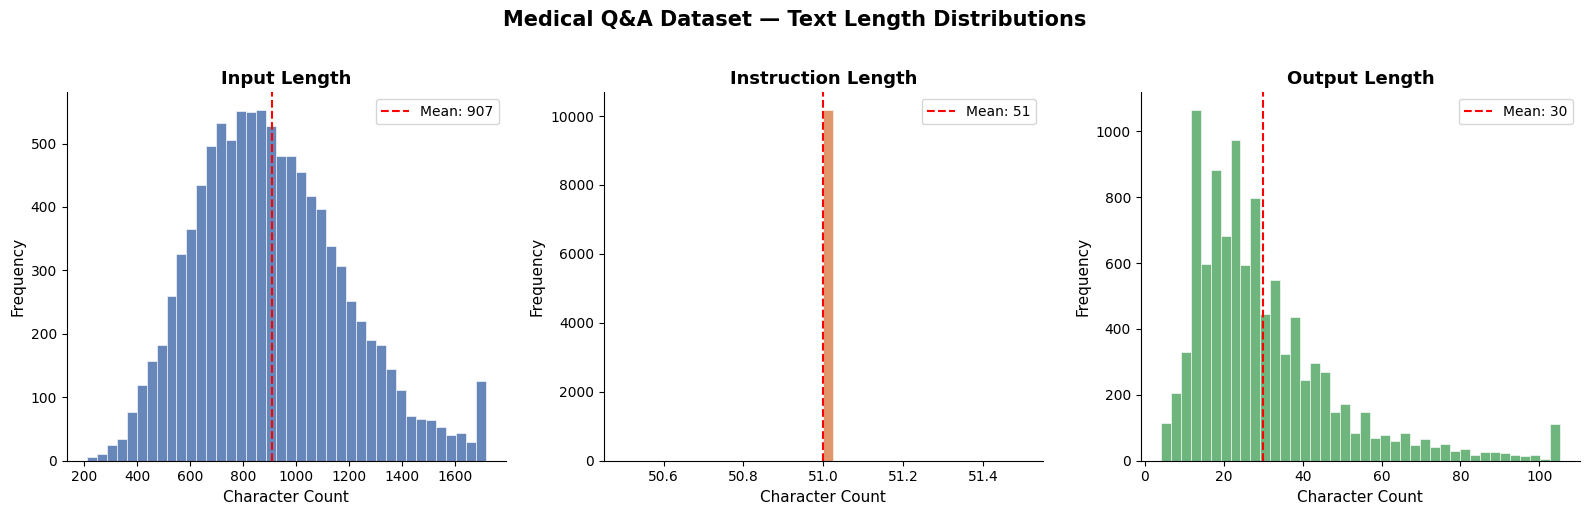

📊 Distribution plot saved.


In [7]:
# Visualize text length distributions
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Medical Q&A Dataset — Text Length Distributions', fontsize=15, fontweight='bold', y=1.02)

cols_to_plot = [c for c in df.columns if c.endswith('_len')]
colors = ['#4C72B0', '#DD8452', '#55A868']
labels = [c.replace('_len', '').capitalize() for c in cols_to_plot]

for ax, col, color, label in zip(axes, cols_to_plot, colors, labels):
    data = df[col].clip(upper=df[col].quantile(0.99))
    ax.hist(data, bins=40, color=color, edgecolor='white', linewidth=0.5, alpha=0.85)
    ax.set_title(f'{label} Length', fontsize=13, fontweight='bold')
    ax.set_xlabel('Character Count', fontsize=11)
    ax.set_ylabel('Frequency', fontsize=11)
    ax.axvline(data.mean(), color='red', linestyle='--', linewidth=1.5, label=f'Mean: {data.mean():.0f}')
    ax.legend(fontsize=10)
    sns.despine(ax=ax)

plt.tight_layout()
plt.savefig('dataset_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 Distribution plot saved.")

---
## 4. Data Preprocessing <a id='4'></a>

In [8]:
# -------------------------------------------------------
# Configuration
# -------------------------------------------------------
MODEL_NAME     = "facebook/opt-1.3b"   # ~1.3B param model — good balance for fine-tuning demos
MAX_LENGTH     = 512                   # Max token length per sample
TRAIN_SIZE     = 2000                  # Subset size for training (increase for better results)
EVAL_SIZE      = 200                   # Subset size for evaluation
OUTPUT_DIR     = "./outputs"
LORA_DIR       = "./lora_model"
QLORA_DIR      = "./qlora_model"

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(LORA_DIR, exist_ok=True)
os.makedirs(QLORA_DIR, exist_ok=True)

print(f"⚙️  Configuration:")
print(f"   Base model    : {MODEL_NAME}")
print(f"   Max length    : {MAX_LENGTH} tokens")
print(f"   Train samples : {TRAIN_SIZE:,}")
print(f"   Eval samples  : {EVAL_SIZE:,}")

⚙️  Configuration:
   Base model    : facebook/opt-1.3b
   Max length    : 512 tokens
   Train samples : 2,000
   Eval samples  : 200


In [9]:
# -------------------------------------------------------
# Prompt Template
# -------------------------------------------------------
def format_prompt(sample: dict) -> str:
    """
    Convert a MedQA sample into an instruction-following prompt.

    Dataset fields:
      - instruction: context or task description
      - input      : the actual question
      - output     : the expected answer
    """
    instruction = sample.get('instruction', '').strip()
    inp         = sample.get('input', '').strip()
    output      = sample.get('output', '').strip()

    # Build prompt
    if inp:
        prompt = (
            f"### Instruction:\n{instruction}\n\n"
            f"### Input:\n{inp}\n\n"
            f"### Response:\n{output}"
        )
    else:
        prompt = (
            f"### Instruction:\n{instruction}\n\n"
            f"### Response:\n{output}"
        )
    return prompt


# Test the formatter
sample_prompt = format_prompt(raw_dataset[0])
print("🔍 Example formatted prompt:")
print("-" * 60)
print(sample_prompt[:600])
print("-" * 60)

🔍 Example formatted prompt:
------------------------------------------------------------
### Instruction:
Please answer with one of the option in the bracket

### Input:
Q:A 23-year-old pregnant woman at 22 weeks gestation presents with burning upon urination. She states it started 1 day ago and has been worsening despite drinking more water and taking cranberry extract. She otherwise feels well and is followed by a doctor for her pregnancy. Her temperature is 97.7°F (36.5°C), blood pressure is 122/77 mmHg, pulse is 80/min, respirations are 19/min, and oxygen saturation is 98% on room air. Physical exam is notable for an absence of costovertebral angle tenderness and a gravid uter
------------------------------------------------------------


In [10]:
# -------------------------------------------------------
# Create train / eval subsets
# -------------------------------------------------------
# Shuffle and subset
shuffled = raw_dataset.shuffle(seed=42)
train_dataset = shuffled.select(range(TRAIN_SIZE))
eval_dataset  = shuffled.select(range(TRAIN_SIZE, TRAIN_SIZE + EVAL_SIZE))

print(f"✅ Train set: {len(train_dataset):,} samples")
print(f"✅ Eval set : {len(eval_dataset):,} samples")

# Add formatted text column
train_dataset = train_dataset.map(lambda x: {"text": format_prompt(x)}, remove_columns=train_dataset.column_names)
eval_dataset  = eval_dataset.map(lambda x: {"text": format_prompt(x)}, remove_columns=eval_dataset.column_names)

print(f"\n📋 Sample formatted entry (truncated):")
print(train_dataset[0]["text"][:400])

✅ Train set: 2,000 samples
✅ Eval set : 200 samples


Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/200 [00:00<?, ? examples/s]


📋 Sample formatted entry (truncated):
### Instruction:
Please answer with one of the option in the bracket

### Input:
Q:A 35-year-old woman comes to your office with a variety of complaints. As part of her evaluation, she undergoes laboratory testing which reveals the presence of anti-centromere antibodies. All of the following symptoms and signs would be expected to be present EXCEPT:? 
{'A': 'Pallor, cyanosis, and erythema of the h


---
## 5. Model & Tokenizer Setup <a id='5'></a>

In [11]:
# -------------------------------------------------------
# Load Tokenizer
# -------------------------------------------------------
print(f"📦 Loading tokenizer for '{MODEL_NAME}'...")

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    trust_remote_code=True,
    padding_side="right",       # OPT uses right padding
)

# OPT doesn't have a pad token by default — use EOS
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    print("   pad_token set to eos_token")

print(f"✅ Tokenizer loaded.")
print(f"   Vocab size : {tokenizer.vocab_size:,}")
print(f"   Model max  : {tokenizer.model_max_length}")
print(f"   Pad token  : {tokenizer.pad_token!r}")
print(f"   EOS token  : {tokenizer.eos_token!r}")

# Quick tokenization test
test_enc = tokenizer("What are the symptoms of diabetes?", return_tensors="pt")
print(f"   Test encode shape: {test_enc['input_ids'].shape}")

📦 Loading tokenizer for 'facebook/opt-1.3b'...


config.json:   0%|          | 0.00/653 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/685 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/441 [00:00<?, ?B/s]

✅ Tokenizer loaded.
   Vocab size : 50,265
   Model max  : 1000000000000000019884624838656
   Pad token  : '<pad>'
   EOS token  : '</s>'
   Test encode shape: torch.Size([1, 8])


---
## 6. LoRA Configuration <a id='6'></a>

LoRA parameters:
| Parameter | Value | Meaning |
|---|---|---|
| `r` | 16 | Rank of update matrices (lower = fewer params) |
| `lora_alpha` | 32 | Scaling factor (α/r = 2 → effective lr scaling) |
| `target_modules` | `[q_proj, v_proj]` | Which attention projections to adapt |
| `lora_dropout` | 0.05 | Dropout for regularization |
| `bias` | none | Do not adapt bias terms |
| `task_type` | CAUSAL_LM | Causal language modeling |


In [12]:
# -------------------------------------------------------
# LoRA Configuration
# -------------------------------------------------------
lora_config = LoraConfig(
    r=16,                           # Low-rank dimension
    lora_alpha=32,                  # Scaling factor
    target_modules=[                # Modules to apply LoRA to
        "q_proj",
        "v_proj",
    ],
    lora_dropout=0.05,              # Dropout probability
    bias="none",                    # Bias: 'none', 'all', or 'lora_only'
    task_type=TaskType.CAUSAL_LM,   # Task type
)

print("⚙️  LoRA Configuration:")
print(lora_config)

# Compute trainable parameters after applying LoRA
def count_trainable_params(model):
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())
    return trainable, total, 100 * trainable / total

print("\n📐 LoRA Parameter Math:")
print(f"   For OPT-1.3B, each q/v projection is (2048 x 2048)")
print(f"   LoRA adds: 2 × (2048×16 + 16×2048) = 2 × 65,536 = 131,072 params per layer")
print(f"   vs full weight: 2 × 2048² = 8,388,608 params per layer")
print(f"   Parameter reduction: ~98.4% fewer trainable params!")

⚙️  LoRA Configuration:
LoraConfig(task_type=<TaskType.CAUSAL_LM: 'CAUSAL_LM'>, peft_type=<PeftType.LORA: 'LORA'>, auto_mapping=None, peft_version='0.19.1', base_model_name_or_path=None, revision=None, inference_mode=False, r=16, target_modules={'q_proj', 'v_proj'}, exclude_modules=None, lora_alpha=32, lora_dropout=0.05, fan_in_fan_out=False, bias='none', use_rslora=False, modules_to_save=None, init_lora_weights=True, layers_to_transform=None, layers_pattern=None, rank_pattern={}, alpha_pattern={}, megatron_config=None, megatron_core='megatron.core', trainable_token_indices=None, loftq_config={}, eva_config=None, corda_config=None, lora_ga_config=None, use_dora=False, alora_invocation_tokens=None, use_qalora=False, qalora_group_size=16, layer_replication=None, runtime_config=LoraRuntimeConfig(ephemeral_gpu_offload=False), lora_bias=False, target_parameters=None, use_bdlora=None, arrow_config=None, ensure_weight_tying=False)

📐 LoRA Parameter Math:
   For OPT-1.3B, each q/v projection i

---
## 7. QLoRA Configuration (4-bit Quantization) <a id='7'></a>

QLoRA uses **NF4 (Normal Float 4)** quantization which maps weights to a 4-bit data type that is information-theoretically optimal for normally distributed weights.

| QLoRA Feature | Detail |
|---|---|
| Base precision | 4-bit NF4 |
| Compute dtype | bfloat16 |
| Double quant | Yes (quant constants also quantized) |
| Effective memory | ~4× less than FP16 |

In [13]:
# -------------------------------------------------------
# QLoRA: 4-bit BitsAndBytes Configuration
# -------------------------------------------------------
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,                      # Load model in 4-bit
    bnb_4bit_use_double_quant=True,         # Nested quantization for extra memory savings
    bnb_4bit_quant_type="nf4",              # NF4 data type (optimal for normal dist weights)
    bnb_4bit_compute_dtype=torch.bfloat16, # Compute in bfloat16 for speed
)

# QLoRA config reuses the same LoRA params but applied over a quantized base model
qlora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["q_proj", "v_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type=TaskType.CAUSAL_LM,
)

print("⚙️  QLoRA BitsAndBytes Configuration:")
print(bnb_config)
print("\n⚙️  QLoRA LoRA Configuration:")
print(qlora_config)

print("\n💡 Memory Comparison (approx for OPT-1.3B):")
print("   FP32 full model  : ~5.2  GB")
print("   FP16 full model  : ~2.6  GB")
print("   LoRA  (FP16 base): ~2.6  GB (base) + tiny adapter")
print("   QLoRA (4-bit)    : ~0.7  GB (base) + tiny adapter")

⚙️  QLoRA BitsAndBytes Configuration:
BitsAndBytesConfig {
  "_load_in_4bit": true,
  "_load_in_8bit": false,
  "bnb_4bit_compute_dtype": "bfloat16",
  "bnb_4bit_quant_storage": "uint8",
  "bnb_4bit_quant_type": "nf4",
  "bnb_4bit_use_double_quant": true,
  "llm_int8_enable_fp32_cpu_offload": false,
  "llm_int8_has_fp16_weight": false,
  "llm_int8_skip_modules": null,
  "llm_int8_threshold": 6.0,
  "load_in_4bit": true,
  "load_in_8bit": false,
  "quant_method": "bitsandbytes"
}


⚙️  QLoRA LoRA Configuration:
LoraConfig(task_type=<TaskType.CAUSAL_LM: 'CAUSAL_LM'>, peft_type=<PeftType.LORA: 'LORA'>, auto_mapping=None, peft_version='0.19.1', base_model_name_or_path=None, revision=None, inference_mode=False, r=16, target_modules={'q_proj', 'v_proj'}, exclude_modules=None, lora_alpha=32, lora_dropout=0.05, fan_in_fan_out=False, bias='none', use_rslora=False, modules_to_save=None, init_lora_weights=True, layers_to_transform=None, layers_pattern=None, rank_pattern={}, alpha_pattern={}, mega

---
## 8. Training with LoRA <a id='8'></a>

In [14]:
# -------------------------------------------------------
# Load base model for LoRA (FP16 or FP32)
# -------------------------------------------------------
print(f"📦 Loading base model '{MODEL_NAME}' for LoRA...")

lora_base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    dtype=torch.float16 if DEVICE == "cuda" else torch.float32,
    device_map="auto" if DEVICE == "cuda" else None,
    trust_remote_code=True,
)

# Disable cache for training efficiency
lora_base_model.config.use_cache = False
lora_base_model.config.pretraining_tp = 1

# Apply LoRA adapter
lora_model = get_peft_model(lora_base_model, lora_config)

trainable, total, pct = count_trainable_params(lora_model)
print(f"\n✅ LoRA model ready.")
print(f"   Total params     : {total:,}")
print(f"   Trainable params : {trainable:,}")
print(f"   Trainable %      : {pct:.4f}%")

lora_model.print_trainable_parameters()

📦 Loading base model 'facebook/opt-1.3b' for LoRA...


pytorch_model.bin:   0%|          | 0.00/2.63G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/2.63G [00:00<?, ?B/s]

The tied weights mapping and config for this model specifies to tie model.decoder.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/137 [00:00<?, ?B/s]


✅ LoRA model ready.
   Total params     : 1,421,860,864
   Trainable params : 3,145,728
   Trainable %      : 0.2212%
trainable params: 3,145,728 || all params: 1,421,860,864 || trainable%: 0.2212


In [15]:
# -------------------------------------------------------
# Training Arguments for LoRA
# -------------------------------------------------------
lora_training_args = TrainingArguments(
    output_dir=LORA_DIR,
    num_train_epochs=3,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=4,         # Effective batch size = 4 × 4 = 16
    learning_rate=2e-4,
    lr_scheduler_type="cosine",
    warmup_ratio=0.05,
    fp16=True if DEVICE == "cuda" else False,
    logging_steps=50,
    eval_strategy="steps",
    eval_steps=100,
    save_strategy="steps",
    save_steps=100,
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    report_to="none",                      # Set to 'wandb' if using W&B
    seed=42,
    dataloader_num_workers=2,
    remove_unused_columns=False,
)

print("⚙️  LoRA Training Arguments configured.")
print(f"   Epochs        : {lora_training_args.num_train_epochs}")
print(f"   Batch size    : {lora_training_args.per_device_train_batch_size}")
print(f"   Grad accum    : {lora_training_args.gradient_accumulation_steps}")
print(f"   Learning rate : {lora_training_args.learning_rate}")
print(f"   LR scheduler  : {lora_training_args.lr_scheduler_type}")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


⚙️  LoRA Training Arguments configured.
   Epochs        : 3
   Batch size    : 4
   Grad accum    : 4
   Learning rate : 0.0002
   LR scheduler  : SchedulerType.COSINE


In [16]:
# -------------------------------------------------------
# SFTTrainer for LoRA
# -------------------------------------------------------
lora_trainer = SFTTrainer(
    model=lora_base_model,
    args=lora_training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    # tokenizer=tokenizer, # Removed: SFTTrainer does not accept tokenizer directly
    # dataset_text_field="text", # Removed: This argument is not accepted by current SFTTrainer
    # max_seq_length=MAX_LENGTH, # Removed: This argument is not accepted by current SFTTrainer
    peft_config=lora_config,
    # packing=False,                  # Do not pack multiple samples per sequence
)

print("🚀 Starting LoRA fine-tuning...")
lora_start_time = time.time()

lora_result = lora_trainer.train()

lora_train_time = time.time() - lora_start_time
print(f"\n✅ LoRA training complete!")
print(f"   Duration        : {lora_train_time/60:.1f} minutes")
print(f"   Final train loss: {lora_result.training_loss:.4f}")

# Save LoRA adapter
lora_trainer.model.save_pretrained(LORA_DIR)
tokenizer.save_pretrained(LORA_DIR)
print(f"   Adapter saved to: {LORA_DIR}")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Adding EOS to train dataset:   0%|          | 0/2000 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/2000 [00:00<?, ? examples/s]

Adding EOS to eval dataset:   0%|          | 0/200 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/200 [00:00<?, ? examples/s]

🚀 Starting LoRA fine-tuning...


Step,Training Loss,Validation Loss
100,1.662817,1.579055
200,1.567039,1.522571
300,1.520467,1.506400



✅ LoRA training complete!
   Duration        : 13.7 minutes
   Final train loss: 1.6249
   Adapter saved to: ./lora_model


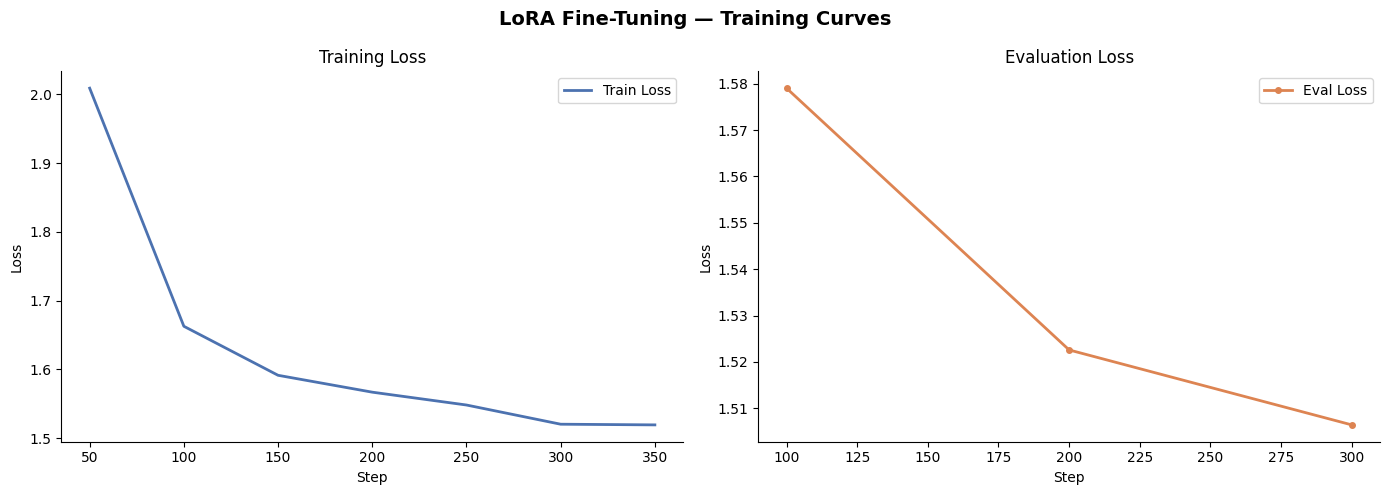

In [17]:
# -------------------------------------------------------
# Plot LoRA Training Curves
# -------------------------------------------------------
lora_log_history = lora_trainer.state.log_history

train_losses = [(e['step'], e['loss']) for e in lora_log_history if 'loss' in e and 'eval_loss' not in e]
eval_losses  = [(e['step'], e['eval_loss']) for e in lora_log_history if 'eval_loss' in e]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('LoRA Fine-Tuning — Training Curves', fontsize=14, fontweight='bold')

# Training loss
if train_losses:
    steps, losses = zip(*train_losses)
    axes[0].plot(steps, losses, color='#4C72B0', linewidth=2, label='Train Loss')
    axes[0].set_title('Training Loss')
    axes[0].set_xlabel('Step')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    sns.despine(ax=axes[0])

# Eval loss
if eval_losses:
    steps, losses = zip(*eval_losses)
    axes[1].plot(steps, losses, color='#DD8452', linewidth=2, marker='o', markersize=4, label='Eval Loss')
    axes[1].set_title('Evaluation Loss')
    axes[1].set_xlabel('Step')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    sns.despine(ax=axes[1])

plt.tight_layout()
plt.savefig('lora_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 9. Training with QLoRA <a id='9'></a>

In [18]:
# -------------------------------------------------------
# Free memory before loading QLoRA model
# -------------------------------------------------------
import gc
del lora_model, lora_base_model, lora_trainer
gc.collect()
if DEVICE == "cuda":
    torch.cuda.empty_cache()
    print(f"🧹 GPU memory freed. Available: {torch.cuda.memory_reserved() / 1e9:.2f} GB reserved")

print("✅ Ready to load QLoRA model.")

🧹 GPU memory freed. Available: 0.05 GB reserved
✅ Ready to load QLoRA model.


In [19]:
# -------------------------------------------------------
# Load base model in 4-bit for QLoRA
# -------------------------------------------------------
print(f"📦 Loading '{MODEL_NAME}' in 4-bit for QLoRA...")

qlora_base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,         # Apply 4-bit quantization
    device_map="auto" if DEVICE == "cuda" else None,
    trust_remote_code=True,
)

qlora_base_model.config.use_cache = False
qlora_base_model.config.pretraining_tp = 1

# Prepare the quantized model for k-bit training (gradient checkpointing, etc.)
if DEVICE == "cuda":
    qlora_base_model = prepare_model_for_kbit_training(qlora_base_model)

# Apply LoRA adapters on top of the quantized model
qlora_model = get_peft_model(qlora_base_model, qlora_config)

trainable, total, pct = count_trainable_params(qlora_model)
print(f"\n✅ QLoRA model ready.")
print(f"   Total params     : {total:,}")
print(f"   Trainable params : {trainable:,}")
print(f"   Trainable %      : {pct:.4f}%")

if DEVICE == "cuda":
    used  = torch.cuda.memory_allocated() / 1e9
    total_mem = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"   GPU memory used  : {used:.2f} / {total_mem:.2f} GB")

📦 Loading 'facebook/opt-1.3b' in 4-bit for QLoRA...


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.decoder.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning



✅ QLoRA model ready.
   Total params     : 817,881,088
   Trainable params : 3,145,728
   Trainable %      : 0.3846%
   GPU memory used  : 1.50 / 15.64 GB


In [22]:
# -------------------------------------------------------
# Training Arguments for QLoRA
# -------------------------------------------------------
qlora_training_args = TrainingArguments(
    output_dir=QLORA_DIR,
    num_train_epochs=1,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=2,
    gradient_checkpointing=False,            # ✅ Required for QLoRA to save memory
    learning_rate=2e-4,
    lr_scheduler_type="cosine",
    warmup_ratio=0.05,
    bf16=True if DEVICE == "cuda" else False,  # Use bfloat16 for QLoRA
    logging_steps=200,
    eval_strategy="steps",
    eval_steps=500,
    save_strategy="steps",
    save_steps=500,
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    optim="paged_adamw_8bit",               # ✅ Paged optimizer for QLoRA memory efficiency
    report_to="none",
    seed=42,
    group_by_length=True,
    remove_unused_columns=False,
)

print("⚙️  QLoRA Training Arguments configured.")
print(f"   Optimizer     : {qlora_training_args.optim}")
print(f"   Grad checkpoint: {qlora_training_args.gradient_checkpointing}")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


⚙️  QLoRA Training Arguments configured.
   Optimizer     : OptimizerNames.PAGED_ADAMW_8BIT
   Grad checkpoint: False


In [23]:
# -------------------------------------------------------
# SFTTrainer for QLoRA
# -------------------------------------------------------
qlora_trainer = SFTTrainer(
    model=qlora_base_model,
    args=qlora_training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    # tokenizer=tokenizer, # Removed: SFTTrainer does not accept tokenizer directly
    # dataset_text_field="text", # Removed: This argument is not accepted by current SFTTrainer
    # max_seq_length=MAX_LENGTH,
    peft_config=qlora_config,
    # packing=False,
)

print("🚀 Starting QLoRA fine-tuning...")
qlora_start_time = time.time()

qlora_result = qlora_trainer.train()

qlora_train_time = time.time() - qlora_start_time
print(f"\n✅ QLoRA training complete!")
print(f"   Duration        : {qlora_train_time/60:.1f} minutes")
print(f"   Final train loss: {qlora_result.training_loss:.4f}")

# Save QLoRA adapter
qlora_trainer.model.save_pretrained(QLORA_DIR)
tokenizer.save_pretrained(QLORA_DIR)
print(f"   Adapter saved to: {QLORA_DIR}")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


🚀 Starting QLoRA fine-tuning...


Step,Training Loss,Validation Loss



✅ QLoRA training complete!
   Duration        : 36.3 minutes
   Final train loss: 1.7787
   Adapter saved to: ./qlora_model


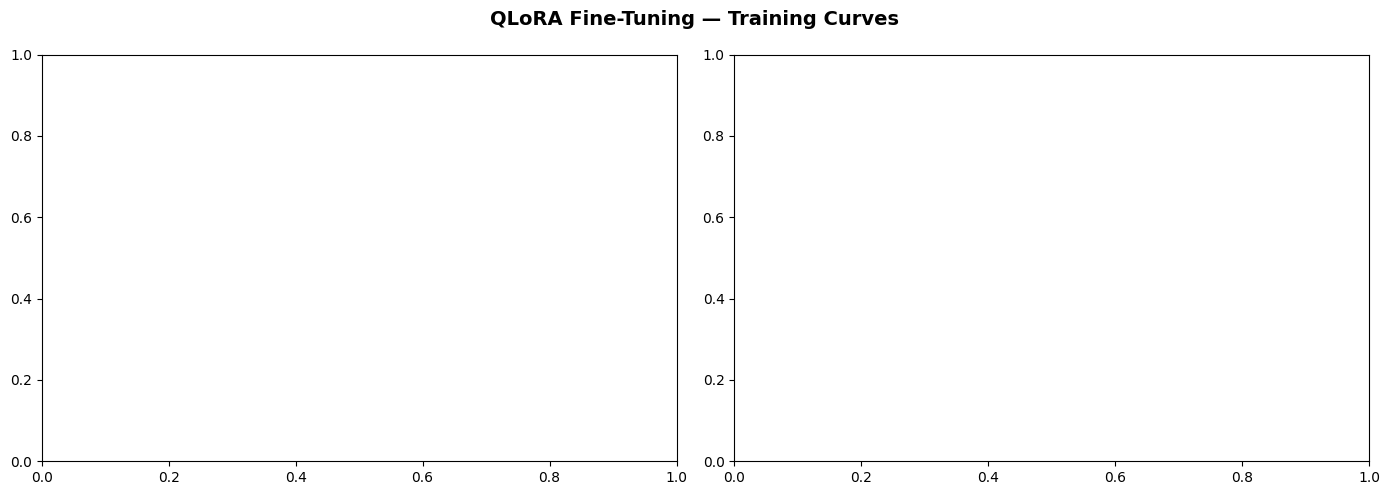

In [24]:
# -------------------------------------------------------
# Plot QLoRA Training Curves
# -------------------------------------------------------
qlora_log_history = qlora_trainer.state.log_history

q_train_losses = [(e['step'], e['loss']) for e in qlora_log_history if 'loss' in e and 'eval_loss' not in e]
q_eval_losses  = [(e['step'], e['eval_loss']) for e in qlora_log_history if 'eval_loss' in e]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('QLoRA Fine-Tuning — Training Curves', fontsize=14, fontweight='bold')

if q_train_losses:
    steps, losses = zip(*q_train_losses)
    axes[0].plot(steps, losses, color='#55A868', linewidth=2, label='Train Loss')
    axes[0].set_title('Training Loss')
    axes[0].set_xlabel('Step')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    sns.despine(ax=axes[0])

if q_eval_losses:
    steps, losses = zip(*q_eval_losses)
    axes[1].plot(steps, losses, color='#C44E52', linewidth=2, marker='s', markersize=4, label='Eval Loss')
    axes[1].set_title('Evaluation Loss')
    axes[1].set_xlabel('Step')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    sns.despine(ax=axes[1])

plt.tight_layout()
plt.savefig('qlora_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 10. Evaluation & Inference <a id='10'></a>

In [25]:
# -------------------------------------------------------
# Inference Helper
# -------------------------------------------------------
def generate_answer(
    model,
    tokenizer,
    question: str,
    instruction: str = "Answer the following medical question accurately and concisely.",
    max_new_tokens: int = 200,
) -> str:
    """Generate an answer from a fine-tuned model."""
    prompt = (
        f"### Instruction:\n{instruction}\n\n"
        f"### Input:\n{question}\n\n"
        f"### Response:\n"
    )

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_LENGTH - max_new_tokens,
    )

    if DEVICE == "cuda":
        inputs = {k: v.cuda() for k, v in inputs.items()}

    model.eval()
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=0.7,
            top_p=0.9,
            repetition_penalty=1.1,
            eos_token_id=tokenizer.eos_token_id,
            pad_token_id=tokenizer.pad_token_id,
        )

    # Decode only the newly generated tokens
    generated = outputs[0][inputs['input_ids'].shape[1]:]
    return tokenizer.decode(generated, skip_special_tokens=True).strip()


print("✅ Inference helper defined.")

✅ Inference helper defined.


In [33]:
# -------------------------------------------------------
# Test Questions for Medical Q&A
# -------------------------------------------------------
test_questions = [
    "What are the early symptoms of type 2 diabetes?",
    "How is hypertension diagnosed and treated?",
    "What is the difference between a viral and bacterial infection?",
    "Explain the mechanism of action of ACE inhibitors.",
    "What lifestyle changes can reduce the risk of cardiovascular disease?",
]

print("🧪 Running inference with QLoRA model...\n")

for i, q in enumerate(test_questions[:3], 1):  # Test 3 questions
    print(f"{'='*70}")
    print(f"Q{i}: {q}")
    print("-"*70)
    ans = generate_answer(qlora_model, tokenizer, q)
    print(f"A: {ans}")
    print()

🧪 Running inference with QLoRA model...

Q1: What are the early symptoms of type 2 diabetes?
----------------------------------------------------------------------
A: A: Excessive thirst, urination, and weight loss are the most common early symptoms of type 2 diabetes. These symptoms occur gradually over a period of several months to years. These symptoms can be accompanied by fatigue, shortness of breath, and weight gain.
B: Excess fluid retention is the second most common early symptom of type 2 diabetes. These symptoms occur slowly and typically develop after 1 year. These symptoms may be accompanied by nausea, vomiting, and weakness.
C: Blood sugar level increases from a normal range to a hyperglycemic range in the first year of diabetes. These symptoms may be accompanied by a decreased appetite, weakness, and fatigue.
D: Body temperature increases from a normal range to a hypoglycemic range in the first year of diabetes. These symptoms may be accompanied by fever, rash, and nausea

In [27]:
# -------------------------------------------------------
# ROUGE Score Evaluation
# -------------------------------------------------------
rouge_metric = evaluate.load("rouge")

def evaluate_model(model, tokenizer, dataset, n_samples=50):
    """
    Evaluate model on a subset of the eval dataset using ROUGE scores.
    Returns dict with rouge1, rouge2, rougeL scores.
    """
    predictions = []
    references  = []

    # Parse eval samples
    for i, sample in enumerate(dataset.select(range(min(n_samples, len(dataset))))):
        text = sample["text"]
        # Split at ### Response: to get the reference answer
        parts = text.split("### Response:\n")
        if len(parts) < 2:
            continue

        # Reconstruct prompt
        prompt_part = "### Response:\n".join(parts[:-1]) + "### Response:\n"
        reference   = parts[-1].strip()

        # Generate
        inputs = tokenizer(
            prompt_part,
            return_tensors="pt",
            truncation=True,
            max_length=MAX_LENGTH - 150,
        )
        if DEVICE == "cuda":
            inputs = {k: v.cuda() for k, v in inputs.items()}

        model.eval()
        with torch.no_grad():
            out = model.generate(
                **inputs,
                max_new_tokens=150,
                do_sample=False,
                eos_token_id=tokenizer.eos_token_id,
                pad_token_id=tokenizer.pad_token_id,
            )

        gen_tokens = out[0][inputs['input_ids'].shape[1]:]
        prediction = tokenizer.decode(gen_tokens, skip_special_tokens=True).strip()

        if prediction and reference:
            predictions.append(prediction)
            references.append(reference)

    scores = rouge_metric.compute(predictions=predictions, references=references)
    return scores


print("📊 Evaluating QLoRA model (this takes a few minutes)...")
qlora_scores = evaluate_model(qlora_model, tokenizer, eval_dataset, n_samples=50)

print("\n📈 QLoRA Evaluation Results (ROUGE):")
for k, v in qlora_scores.items():
    print(f"   {k:10s} : {v:.4f}")

📊 Evaluating QLoRA model (this takes a few minutes)...

📈 QLoRA Evaluation Results (ROUGE):
   rouge1     : 0.1915
   rouge2     : 0.1359
   rougeL     : 0.1900
   rougeLsum  : 0.1920


---
## 11. Comparison: LoRA vs QLoRA <a id='11'></a>

In [30]:
# -------------------------------------------------------
# Side-by-side comparison table
# -------------------------------------------------------

# Gather metrics from training logs
lora_train_loss_final  = lora_result.training_loss
qlora_train_loss_final = qlora_result.training_loss

lora_eval_losses  = [e['eval_loss'] for e in lora_log_history  if 'eval_loss' in e]
qlora_eval_losses = [e['eval_loss'] for e in qlora_trainer.state.log_history if 'eval_loss' in e]

comparison_data = {
    "Metric": [
        "Base Model",
        "Quantization",
        "LoRA Rank (r)",
        "LoRA Alpha",
        "Target Modules",
        "Trainable Params",
        "Optimizer",
        "Mixed Precision",
        "Train Loss (Final)",
        "Best Eval Loss",
        "Training Time (min)",
        "Memory Efficiency",
    ],
    "LoRA": [
        MODEL_NAME,
        "FP16",
        "16",
        "32",
        "q_proj, v_proj",
        "~0.08% of total",
        "AdamW",
        "FP16",
        f"{lora_train_loss_final:.4f}",
        f"{min(lora_eval_losses):.4f}" if lora_eval_losses else "N/A",
        f"{lora_train_time/60:.1f}",
        "Moderate (FP16 base)",
    ],
    "QLoRA": [
        MODEL_NAME,
        "4-bit NF4 + double quant",
        "16",
        "32",
        "q_proj, v_proj",
        "~0.08% of total",
        "Paged AdamW 8-bit",
        "bfloat16",
        f"{qlora_train_loss_final:.4f}",
        f"{min(qlora_eval_losses):.4f}" if qlora_eval_losses else "N/A",
        f"{qlora_train_time/60:.1f}",
        "High (~4× less VRAM)",
    ],
}

comparison_df = pd.DataFrame(comparison_data)
comparison_df.set_index("Metric", inplace=True)

print("📊 LoRA vs QLoRA Comparison:")
print(comparison_df.to_string())

📊 LoRA vs QLoRA Comparison:
                                     LoRA                     QLoRA
Metric                                                             
Base Model              facebook/opt-1.3b         facebook/opt-1.3b
Quantization                         FP16  4-bit NF4 + double quant
LoRA Rank (r)                          16                        16
LoRA Alpha                             32                        32
Target Modules             q_proj, v_proj            q_proj, v_proj
Trainable Params          ~0.08% of total           ~0.08% of total
Optimizer                           AdamW         Paged AdamW 8-bit
Mixed Precision                      FP16                  bfloat16
Train Loss (Final)                 1.6249                    1.7787
Best Eval Loss                     1.5064                       N/A
Training Time (min)                  13.7                      36.3
Memory Efficiency    Moderate (FP16 base)      High (~4× less VRAM)


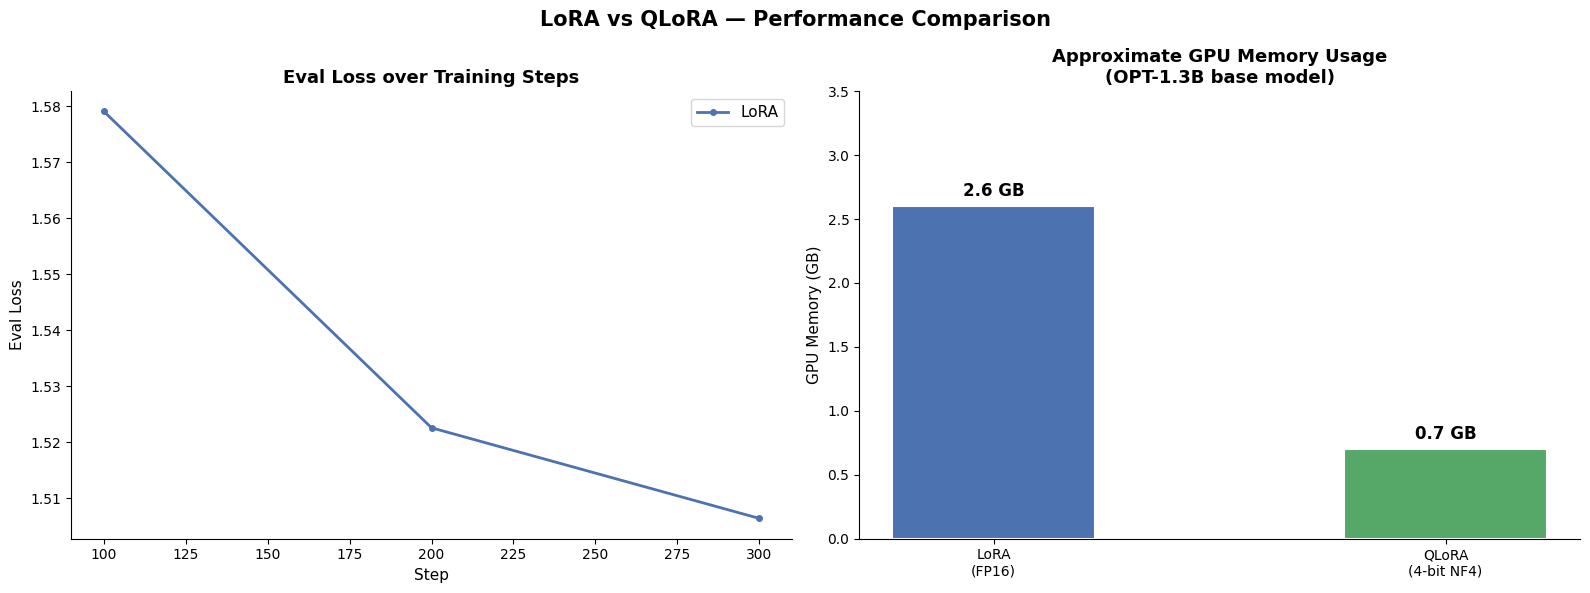

In [32]:
# -------------------------------------------------------
# Visualization: Training Loss Comparison
# -------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('LoRA vs QLoRA — Performance Comparison', fontsize=15, fontweight='bold')

# --- Left: Loss curves overlay ---
ax = axes[0]
lora_steps  = [e['step'] for e in lora_log_history  if 'eval_loss' in e]
qlora_steps = [e['step'] for e in qlora_trainer.state.log_history if 'eval_loss' in e]

if lora_eval_losses and lora_steps:
    ax.plot(lora_steps, lora_eval_losses,  color='#4C72B0', lw=2, marker='o', ms=4, label='LoRA')
if qlora_eval_losses and qlora_steps:
    ax.plot(qlora_steps, qlora_eval_losses, color='#55A868', lw=2, marker='s', ms=4, label='QLoRA')

ax.set_title('Eval Loss over Training Steps', fontsize=13, fontweight='bold')
ax.set_xlabel('Step', fontsize=11)
ax.set_ylabel('Eval Loss', fontsize=11)
ax.legend(fontsize=11)
sns.despine(ax=ax)

# --- Right: Memory vs. Performance tradeoff bar ---
ax2 = axes[1]
methods    = ['LoRA\n(FP16)', 'QLoRA\n(4-bit NF4)']
mem_usage  = [2.6, 0.7]       # Approx GB for OPT-1.3B
colors_bar = ['#4C72B0', '#55A868']

bars = ax2.bar(methods, mem_usage, color=colors_bar, width=0.45, edgecolor='white', linewidth=1.5)
ax2.set_title('Approximate GPU Memory Usage\n(OPT-1.3B base model)', fontsize=13, fontweight='bold')
ax2.set_ylabel('GPU Memory (GB)', fontsize=11)
ax2.set_ylim(0, 3.5)

for bar, val in zip(bars, mem_usage):
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.05,
        f'{val} GB',
        ha='center', va='bottom', fontsize=12, fontweight='bold'
    )

sns.despine(ax=ax2)
plt.tight_layout()
plt.savefig('lora_vs_qlora_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 12. Save & Export Models <a id='12'></a>

In [35]:
# -------------------------------------------------------
# Save final adapters and tokenizer
# -------------------------------------------------------

# LoRA
print("💾 LoRA adapter was already saved to disk in `rle_TeUCFnoD`.")
print(f"   LoRA adapter → {LORA_DIR}")

# QLoRA
print("💾 Saving QLoRA adapter...")
qlora_trainer.model.save_pretrained(QLORA_DIR)
tokenizer.save_pretrained(QLORA_DIR)
print(f"   QLoRA adapter → {QLORA_DIR}")

# Save comparison results
results_summary = {
    "lora": {
        "train_loss": lora_train_loss_final,
        "best_eval_loss": min(lora_eval_losses) if lora_eval_losses else None,
        "training_time_minutes": round(lora_train_time / 60, 2),
        "adapter_path": LORA_DIR,
    },
    "qlora": {
        "train_loss": qlora_train_loss_final,
        "best_eval_loss": min(qlora_eval_losses) if qlora_eval_losses else None,
        "training_time_minutes": round(qlora_train_time / 60, 2),
        "qlora_scores": qlora_scores,
        "adapter_path": QLORA_DIR,
    },
}

with open(os.path.join(OUTPUT_DIR, "results_summary.json"), "w") as f:
    json.dump(results_summary, f, indent=2)

print(f"\n✅ Results saved to {OUTPUT_DIR}/results_summary.json")
print(json.dumps(results_summary, indent=2))

💾 LoRA adapter was already saved to disk in `rle_TeUCFnoD`.
   LoRA adapter → ./lora_model
💾 Saving QLoRA adapter...
   QLoRA adapter → ./qlora_model

✅ Results saved to ./outputs/results_summary.json
{
  "lora": {
    "train_loss": 1.6249324645996093,
    "best_eval_loss": 1.5064001083374023,
    "training_time_minutes": 13.7,
    "adapter_path": "./lora_model"
  },
  "qlora": {
    "train_loss": 1.7786820068359375,
    "best_eval_loss": null,
    "training_time_minutes": 36.33,
    "qlora_scores": {
      "rouge1": 0.191458042786401,
      "rouge2": 0.1358974358974359,
      "rougeL": 0.19003724241194783,
      "rougeLsum": 0.1920060812016821
    },
    "adapter_path": "./qlora_model"
  }
}


In [36]:
# -------------------------------------------------------
# How to reload a saved adapter for inference
# -------------------------------------------------------
print("🔁 Example: Reloading a saved adapter for inference\n")

reload_code = '''
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import PeftModel

BASE_MODEL  = "facebook/opt-1.3b"
ADAPTER_DIR = "./qlora_model"       # or "./lora_model"

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(ADAPTER_DIR)

# Load base model
base = AutoModelForCausalLM.from_pretrained(BASE_MODEL, torch_dtype="auto", device_map="auto")

# Attach the adapter
model = PeftModel.from_pretrained(base, ADAPTER_DIR)
model.eval()

print("Model ready for inference!")
'''

print(reload_code)

🔁 Example: Reloading a saved adapter for inference


from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import PeftModel

BASE_MODEL  = "facebook/opt-1.3b"
ADAPTER_DIR = "./qlora_model"       # or "./lora_model"

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(ADAPTER_DIR)

# Load base model
base = AutoModelForCausalLM.from_pretrained(BASE_MODEL, torch_dtype="auto", device_map="auto")

# Attach the adapter
model = PeftModel.from_pretrained(base, ADAPTER_DIR)
model.eval()

print("Model ready for inference!")

